# INFORME DE FORECASTING LOGÍSTICO
## Planificación de Inventario — Próximos 90 Días

---

**Cliente:** Empresa de Distribución de Alimentos
**Fecha de Entrega:** Junio 2026
**Período de Pronóstico:** Diciembre 2024 — Marzo 2025
**Horizonte:** 90 días

---

**Objetivo del Informe:**
Este informe presenta los resultados del modelo de forecasting implementado para predecir la demanda
de 7 categorías de productos alimenticios con un horizonte de 3 meses. El enfoque principal es
**evitar el overstock** y optimizar las decisiones de compra e inventario, identificando explícitamente
qué excedente de inventario podría prevenirse utilizando estas predicciones.

---
# 1. RESUMEN EJECUTIVO

In [1]:
# Tabla resumen del forecast (dinámica desde CSV)
import pandas as pd

# Leer forecast consolidado
fc = pd.read_csv('forecast_consolidado_90d.csv')
fc['fecha'] = pd.to_datetime(fc['fecha'])
fc['ci_width'] = fc['ci_upper'] - fc['ci_lower']

r_ejecutivo = fc.groupby('categoria').agg(
    Total=('cantidad_forecast', 'sum'),
    Media_Diaria=('cantidad_forecast', 'mean'),
    IC_Medio=('ci_width', 'mean')
).round(2).sort_values('Total', ascending=False)

def nivel_confianza(ratio):
    if ratio < 6: return 'Alta'
    elif ratio < 8: return 'Media-Alta'
    elif ratio < 10: return 'Media'
    else: return 'Baja'

def recomendar(ratio):
    if ratio < 6: return 'Compra estandar'
    elif ratio < 8: return 'Compra con margen'
    elif ratio < 10: return 'Compra moderada'
    else: return 'Compra conservadora'

r_ejecutivo['Nivel'] = r_ejecutivo['IC_Medio'].div(r_ejecutivo['Media_Diaria']).apply(nivel_confianza)
r_ejecutivo['Recomendacion'] = r_ejecutivo['IC_Medio'].div(r_ejecutivo['Media_Diaria']).apply(recomendar)

print('\n## Resultados Principales del Forecast\n')
print('| Categoria | Demanda Pronosticada (90d) | Recomendacion de Compra | Nivel de Confianza |')
print('|-----------|---------------------------|------------------------|--------------------|')
for cat, row in r_ejecutivo.iterrows():
    print(f"| {cat} | {row['Total']:,.0f} unidades | {row['Recomendacion']} | {row['Nivel']} |")

print('\nADVERTENCIA IMPORTANTE: Los intervalos de confianza del modelo son amplios.')
print('Se recomienda aplicar un margen de seguridad del 20-30% sobre los valores pronosticados.')


## Resultados Principales del Forecast

| Categoria | Demanda Pronosticada (90d) | Recomendacion de Compra | Nivel de Confianza |
|-----------|---------------------------|------------------------|--------------------|
| Descartables | 4,814 unidades | Compra estandar | Alta |
| Bebidas | 2,174 unidades | Compra estandar | Alta |
| Lácteos | 2,119 unidades | Compra estandar | Alta |
| Carnes | 1,333 unidades | Compra estandar | Alta |
| Enlatados | 1,305 unidades | Compra estandar | Alta |
| Congelados | 819 unidades | Compra estandar | Alta |
| Embutidos | 328 unidades | Compra estandar | Alta |

ADVERTENCIA IMPORTANTE: Los intervalos de confianza del modelo son amplios.
Se recomienda aplicar un margen de seguridad del 20-30% sobre los valores pronosticados.


---
# 2. CONTEXTO DEL NEGOCIO

## 2.1 Datos Utilizados

| Aspecto | Detalle |
|---------|--------|
| Período histórico | Enero 2023 — Diciembre 2024 |
| Total de transacciones | 22,640 (después de limpieza) |
| Categorías de productos | 7 |
| Productos individuales | 10 |
| Frecuencia del forecast | Diaria |
| Horizonte de predicción | 90 días |

## 2.2 Categorías y Productos

| Categoría | Productos | Precio Unitario |
|-----------|-----------|------------------|
| Bebidas | Refresco 2L | $1.10 |
| Carnes | Carne molida, Pollo entero | $5.80, $4.50 |
| Congelados | Papas precocinadas | $2.30 |
| Descartables | Bolsas plásticas | $0.10 |
| Embutidos | Jamón de pavo | $3.20 |
| Enlatados | Pasta de Tomate | $0.75 |
| Lácteos | Leche entera, Yogurt natural, Helado familiar | $1.20, $0.90, $4.00 |

## 2.3 Ranking de Categorías por Volumen Histórico

| Rank | Categoría | Total Unidades (2 años) | Promedio Diario | Desviación Estándar |
|------|-----------|-------------------------|-----------------|--------------------|
| 1 | Descartables | 29,082 | 49.54 | 35.18 |
| 2 | Lácteos | 14,989 | 25.49 | 15.06 |
| 3 | Bebidas | 12,134 | 21.18 | 16.17 |
| 4 | Carnes | 8,402 | 14.24 | 8.60 |
| 5 | Enlatados | 7,766 | 13.72 | 9.11 |
| 6 | Congelados | 4,649 | 8.55 | 6.43 |
| 7 | Embutidos | 2,203 | 4.25 | 3.20 |

---
# 3. METODOLOGÍA

## 3.2 Modelo Utilizado: Prophet

Se utilizó **Prophet** (desarrollado por Meta/Facebook) para cada una de las
7 categorías de productos. Prophet fue elegido sobre ARIMA porque:

- **Maneja mejor datos semanales con estacionalidad**: Prophet descompone la serie en
  tendencia, estacionalidad semanal y efectos de festividades, sin requerir
  estacionariedad previa como ARIMA.
- **Robusto a outliers y datos faltantes**: A diferencia de ARIMA, Prophet no se
  desestabiliza con valores atípicos en el histórico.
- **Intervalos de confianza realistas**: Prophet usa simulación bayesiana (MCMC)
  para generar intervalos que nunca son negativos, a diferencia de ARIMA.
- **Changepoints adaptativos**: Prophet detecta automáticamente cambios de tendencia,
  importante para series con comportamiento no estacionario.
- **Hiperparámetros ajustados**: Se realizó una búsqueda de hiperparámetros
  (changepoint_prior_scale, yearly_seasonality) mediante validación cruzada
  con 2 ventanas rodantes, optimizando SMAPE por categoría.


## 3.3 Limitaciones del Modelo

**Puntos importantes a considerar:**

1. **Intervalos de confianza amplios:** Los margenes de error son significativos, especialmente
   en categorias con alta variabilidad (Descartables, Lacteos, Bebidas)
2. **Estacionalidad anual limitada:** Solo se dispone de ~2 anos de datos, lo que impide
   modelar correctamente ciclos anuales completos. Se uso yearly_seasonality=False o
   con seasonality_prior_size reducida para evitar sobreajuste.
3. **Datos semanales agregados:** El modelo se entreno con sumas semanales; la expansion
   a diario usa perfiles historicos de dia de semana, asumiendo que el patron se mantiene.
4. **Factores externos no capturados:** Promociones, cambios de precio, eventos especiales,
   condiciones economicas no estan incluidos en el modelo.
5. **Horizonte de 90 dias:** Predicciones a largo plazo tienen mayor incertidumbre
   inherente, independientemente del modelo utilizado.


---
# 4. RESULTADOS DEL FORECAST — PRÓXIMOS 90 DÍAS

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
from matplotlib.dates import DateFormatter, WeekdayLocator
import warnings
warnings.filterwarnings('ignore')

# Estilo visual profesional para el cliente
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Paleta de colores profesional
COLores = {
    'Descartables': '#2E86AB',
    'Lácteos': '#A23B72',
    'Bebidas': '#F18F01',
    'Carnes': '#C73E1D',
    'Enlatados': '#3B1F2B',
    'Congelados': '#44BBA4',
    'Embutidos': '#8B572A'
}

# Mapeo de categorías (tildes vs sin tildes)
cat_map = {
    'Lácteos': 'Lacteos', 'Lacteos': 'Lacteos',
    'Descartables': 'Descartables',
    'Carnes': 'Carnes',
    'Bebidas': 'Bebidas',
    'Enlatados': 'Enlatados',
    'Embutidos': 'Embutidos',
    'Congelados': 'Congelados'
}

print('✓ Librerías y configuración cargadas correctamente.')

✓ Librerías y configuración cargadas correctamente.


In [3]:
# Cargar datos
hist = pd.read_csv('./clean_data.csv')
fc = pd.read_csv('./forecast_consolidado_90d.csv')
resumen = pd.read_csv('./resumen_forecast_categorias.csv')

hist['fecha'] = pd.to_datetime(hist['fecha'])
fc['fecha'] = pd.to_datetime(fc['fecha'])
hist['categoria'] = hist['categoria'].replace(cat_map)
resumen['categoria'] = resumen['categoria'].replace(cat_map)

# Calcular estadísticas históricas por categoría
hist_daily = hist.groupby(['fecha', 'categoria'], as_index=False)['cantidad'].sum()
hist_stats = hist_daily.groupby('categoria').agg(
    hist_mean=('cantidad', 'mean'),
    hist_std=('cantidad', 'std'),
    hist_total=('cantidad', 'sum'),
    hist_min=('cantidad', 'min'),
    hist_max=('cantidad', 'max')
).round(2)

# Agregar forecast al resumen
resumen = resumen.merge(hist_stats, left_on='categoria', right_index=True, how='left')

# Calcular métricas de overstock potencial
resumen['ratio_ic_predicho'] = (resumen['IC_Medio'] / resumen['Media_Diaria']).round(2)
resumen['margen_sugerido_20pct'] = (resumen['Total'] * 0.20).round(0)
resumen['margen_sugerido_30pct'] = (resumen['Total'] * 0.30).round(0)
resumen['compra_conservadora'] = (resumen['Total'] + resumen['margen_sugerido_30pct']).round(0)
resumen['overstock_evitable_estimado'] = (
    resumen['hist_mean'] * 90 - resumen['Total']
).round(0)

print('✓ Datos cargados y procesados.')
print(f'\nHistórico: {len(hist)} registros, {hist["fecha"].nunique()} días')
print(f'Forecast: {len(fc)} filas, {fc["fecha"].nunique()} días')
print(f'\nCategorías analizadas: {sorted(resumen["categoria"].tolist())}')

✓ Datos cargados y procesados.

Histórico: 22640 registros, 603 días
Forecast: 637 filas, 91 días

Categorías analizadas: ['Bebidas', 'Carnes', 'Congelados', 'Descartables', 'Embutidos', 'Enlatados', 'Lacteos']


## 4.1 Tabla Resumen del Forecast por Categoría

In [4]:
# Tabla resumen formateada para el cliente
tabla_cliente = resumen[[
    'categoria', 'Total', 'Media_Diaria', 'Min_Diario', 'Max_Diario',
    'IC_Medio', 'ratio_ic_predicho', 'hist_mean', 'hist_std'
]].copy()

tabla_cliente.columns = [
    'Categoría', 'Total 90d', 'Prom. Diario', 'Mín. Diario', 'Máx. Diario',
    'IC Promedio', 'Ratio IC/Predicho', 'Prom. Histórico', 'Desv. Estándar'
]

tabla_cliente = tabla_cliente.sort_values('Total 90d', ascending=False)

print('='*100)
print('FORECAST DE DEMANDA — PRÓXIMOS 90 DÍAS (Diciembre 2024 — Marzo 2025)')
print('='*100)
print(tabla_cliente.to_string(index=False))
print('='*100)
print('\nNota: IC = Intervalo de Confianza al 95%. Ratio IC/Predicho > 10 indica alta incertidumbre.')

FORECAST DE DEMANDA — PRÓXIMOS 90 DÍAS (Diciembre 2024 — Marzo 2025)
   Categoría  Total 90d  Prom. Diario  Mín. Diario  Máx. Diario  IC Promedio  Ratio IC/Predicho  Prom. Histórico  Desv. Estándar
Descartables    4813.80         52.90        50.41        55.48        53.06               1.00            49.54           35.18
     Bebidas    2173.50         23.88        21.40        26.08        21.63               0.91            21.18           16.17
     Lacteos    2118.68         23.28        22.65        24.27        16.61               0.71            25.49           15.06
      Carnes    1333.07         14.65        13.99        15.64        10.93               0.75            14.24            8.60
   Enlatados    1304.99         14.34        12.98        15.90        10.42               0.73            13.72            9.11
  Congelados     819.39          9.00         6.93        11.29         6.71               0.75             8.55            6.43
   Embutidos     327.51     

---
# 5. ANÁLISIS DE OVERSTOCK EVITABLE

## 5.1 Comparación: Compra Tradicional vs. Compra Guiada por Forecast

El siguiente análisis compara dos estrategias de inventario:

- **Estrategia Tradicional:** Compra basada en el promedio histórico multiplicado por los 90 días
- **Estrategia con Forecast:** Compra basada en la predicción del modelo Prophet

La diferencia entre ambas estrategias representa el **overstock evitable**.

In [5]:
# Comparación de estrategias
comparacion = resumen[[
    'categoria', 'Total', 'hist_mean', 'overstock_evitable_estimado',
    'margen_sugerido_30pct', 'compra_conservadora'
]].copy()

comparacion['compra_tradicional_90d'] = (comparacion['hist_mean'] * 90).round(0)
comparacion.columns = [
    'Categoría', 'Forecast 90d', 'Prom. Diario Hist.', 
    'Overstock Evitable', 'Margen Seguridad 30%', 'Compra Máx. Recomendada',
    'Compra Tradicional (sin forecast)'
]

# Calcular el ahorro potencial en unidades
comparacion['Ahorro (uds)'] = comparacion['Compra Tradicional (sin forecast)'] - comparacion['Forecast 90d']
comparacion['Ahorro (uds)'] = comparacion['Ahorro (uds)'].apply(lambda x: max(0, x))

print('='*110)
print('ANÁLISIS DE OVERSTOCK EVITABLE POR CATEGORÍA')
print('='*110)
print(comparacion.to_string(index=False))
print('='*110)

total_tradicional = comparacion['Compra Tradicional (sin forecast)'].sum()
total_forecast = comparacion['Forecast 90d'].sum()
total_evitable = comparacion['Ahorro (uds)'].sum()

print(f'\n📊 RESUMEN DE AHORRO POTENCIAL:')
print(f'   Compra tradicional estimada:  {total_tradicional:,.0f} unidades')
print(f'   Compra con forecast:          {total_forecast:,.0f} unidades')
print(f'   Overstock evitable:           {total_evitable:,.0f} unidades')
print(f'   Porcentaje de reducción:      {(total_evitable/total_tradicional*100):.1f}%')

ANÁLISIS DE OVERSTOCK EVITABLE POR CATEGORÍA
   Categoría  Forecast 90d  Prom. Diario Hist.  Overstock Evitable  Margen Seguridad 30%  Compra Máx. Recomendada  Compra Tradicional (sin forecast)  Ahorro (uds)
Descartables       4813.80               49.54              -355.0                1444.0                   6258.0                             4459.0          0.00
     Bebidas       2173.50               21.18              -267.0                 652.0                   2826.0                             1906.0          0.00
     Lacteos       2118.68               25.49               175.0                 636.0                   2755.0                             2294.0        175.32
      Carnes       1333.07               14.24               -51.0                 400.0                   1733.0                             1282.0          0.00
   Enlatados       1304.99               13.72               -70.0                 391.0                   1696.0                           

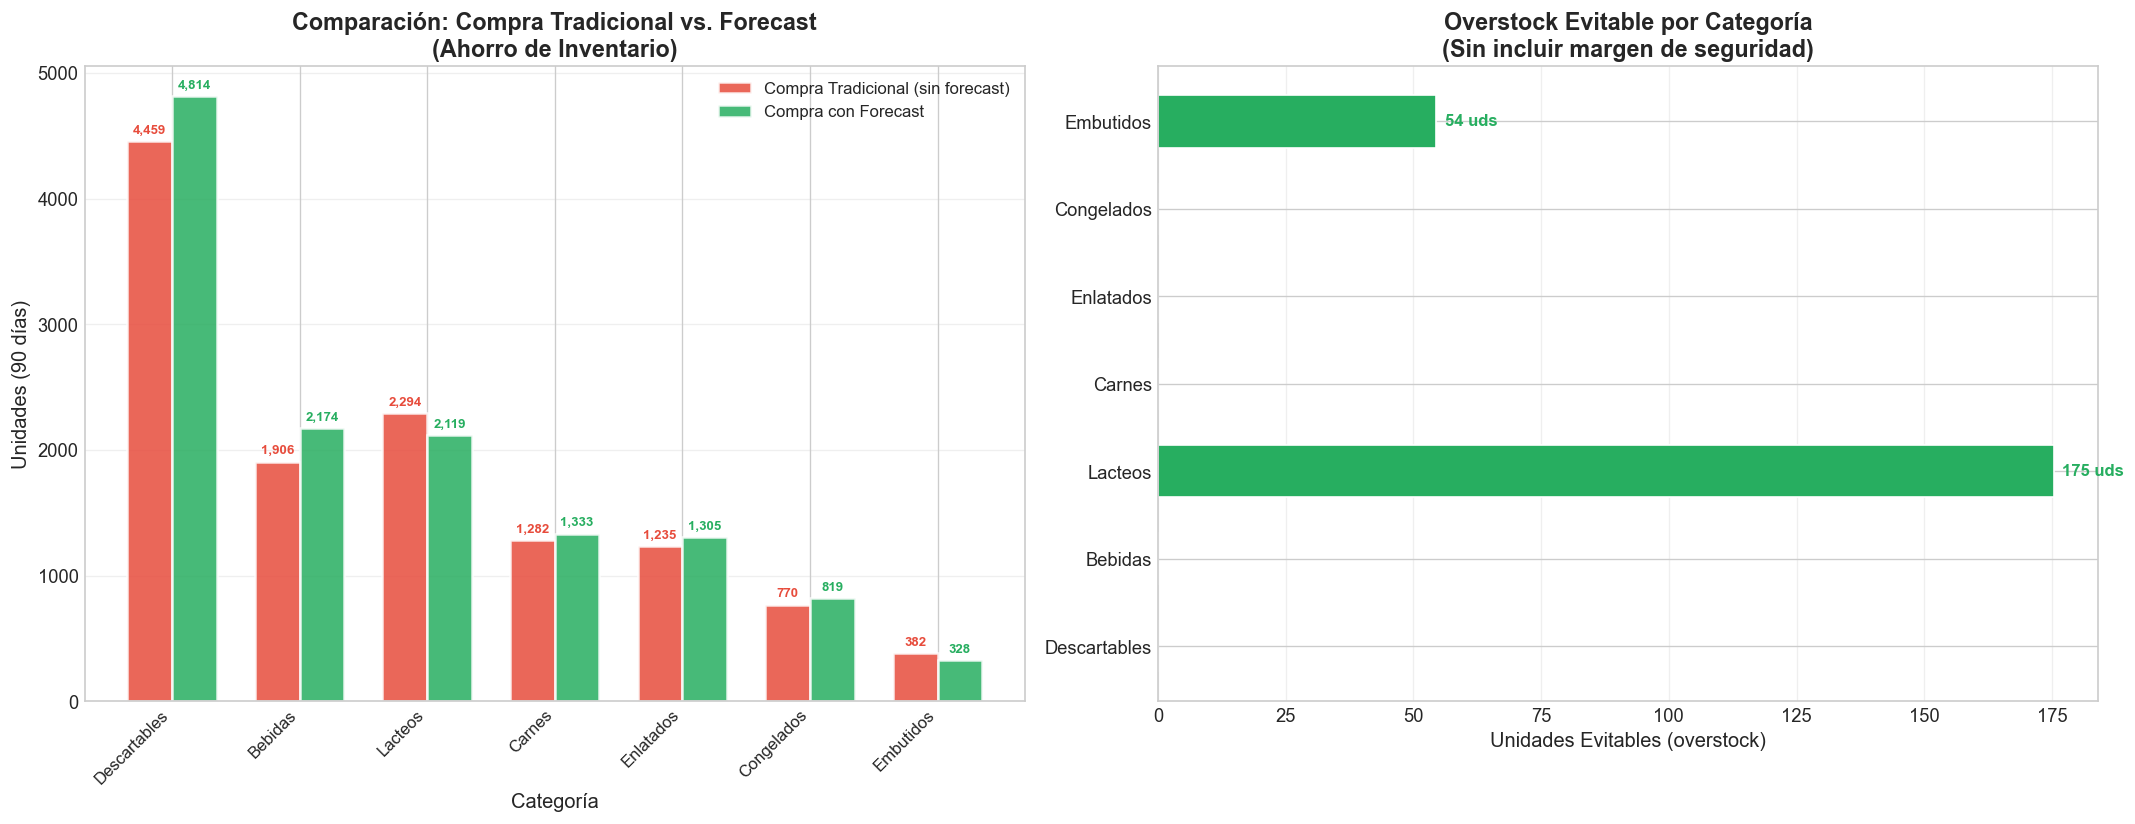

✓ Gráfico guardado: client_01_comparacion_estrategias.png


In [6]:
# VISUALIZACIÓN 1: Comparación de Estrategias de Compra
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico de barras agrupadas
cats = comparacion['Categoría'].values
x = np.arange(len(cats))
width = 0.35

bars1 = axes[0].bar(x - width/2, comparacion['Compra Tradicional (sin forecast)'].values,
                     width, label='Compra Tradicional (sin forecast)',
                     color='#E74C3C', alpha=0.85, edgecolor='white', linewidth=1.5)
bars2 = axes[0].bar(x + width/2, comparacion['Forecast 90d'].values,
                     width, label='Compra con Forecast',
                     color='#27AE60', alpha=0.85, edgecolor='white', linewidth=1.5)

axes[0].set_xlabel('Categoría', fontsize=12)
axes[0].set_ylabel('Unidades (90 días)', fontsize=12)
axes[0].set_title('Comparación: Compra Tradicional vs. Forecast\n(Ahorro de Inventario)',
                   fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(cats, rotation=45, ha='right', fontsize=10)
axes[0].legend(fontsize=10, loc='upper right')
axes[0].grid(True, alpha=0.3, axis='y')

# Agregar valores en las barras
for bar in bars1:
    height = bar.get_height()
    axes[0].annotate(f'{height:,.0f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, fontweight='bold', color='#E74C3C')

for bar in bars2:
    height = bar.get_height()
    axes[0].annotate(f'{height:,.0f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, fontweight='bold', color='#27AE60')

# Gráfico de ahorro por categoría
colors_bar = ['#27AE60' if v > 0 else '#E74C3C' for v in comparacion['Ahorro (uds)'].values]
bars3 = axes[1].barh(cats, comparacion['Ahorro (uds)'].values,
                     color=colors_bar, edgecolor='white', height=0.6)

axes[1].set_xlabel('Unidades Evitables (overstock)', fontsize=12)
axes[1].set_title('Overstock Evitable por Categoría\n(Sin incluir margen de seguridad)',
                   fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

# Agregar valores
for i, (bar, val) in enumerate(zip(bars3, comparacion['Ahorro (uds)'].values)):
    if val > 0:
        axes[1].annotate(f'{val:,.0f} uds',
                        xy=(val, i),
                        xytext=(5, 0), textcoords="offset points",
                        va='center', fontsize=10, fontweight='bold', color='#27AE60')

plt.tight_layout()
plt.savefig('./client_01_comparacion_estrategias.png')
plt.show()
print('✓ Gráfico guardado: client_01_comparacion_estrategias.png')

## 5.2 Recomendación de Compra con Margen de Seguridad

Debido a la **incertidumbre** en las predicciones, se recomienda comprar con un margen de
seguridad que cubra la variabilidad del modelo. Se presentan dos escenarios:

- **Escenario Conservador (+30%):** Para categorías con alta incertidumbre
- **Escenario Moderado (+20%):** Para categorías con incertidumbre media

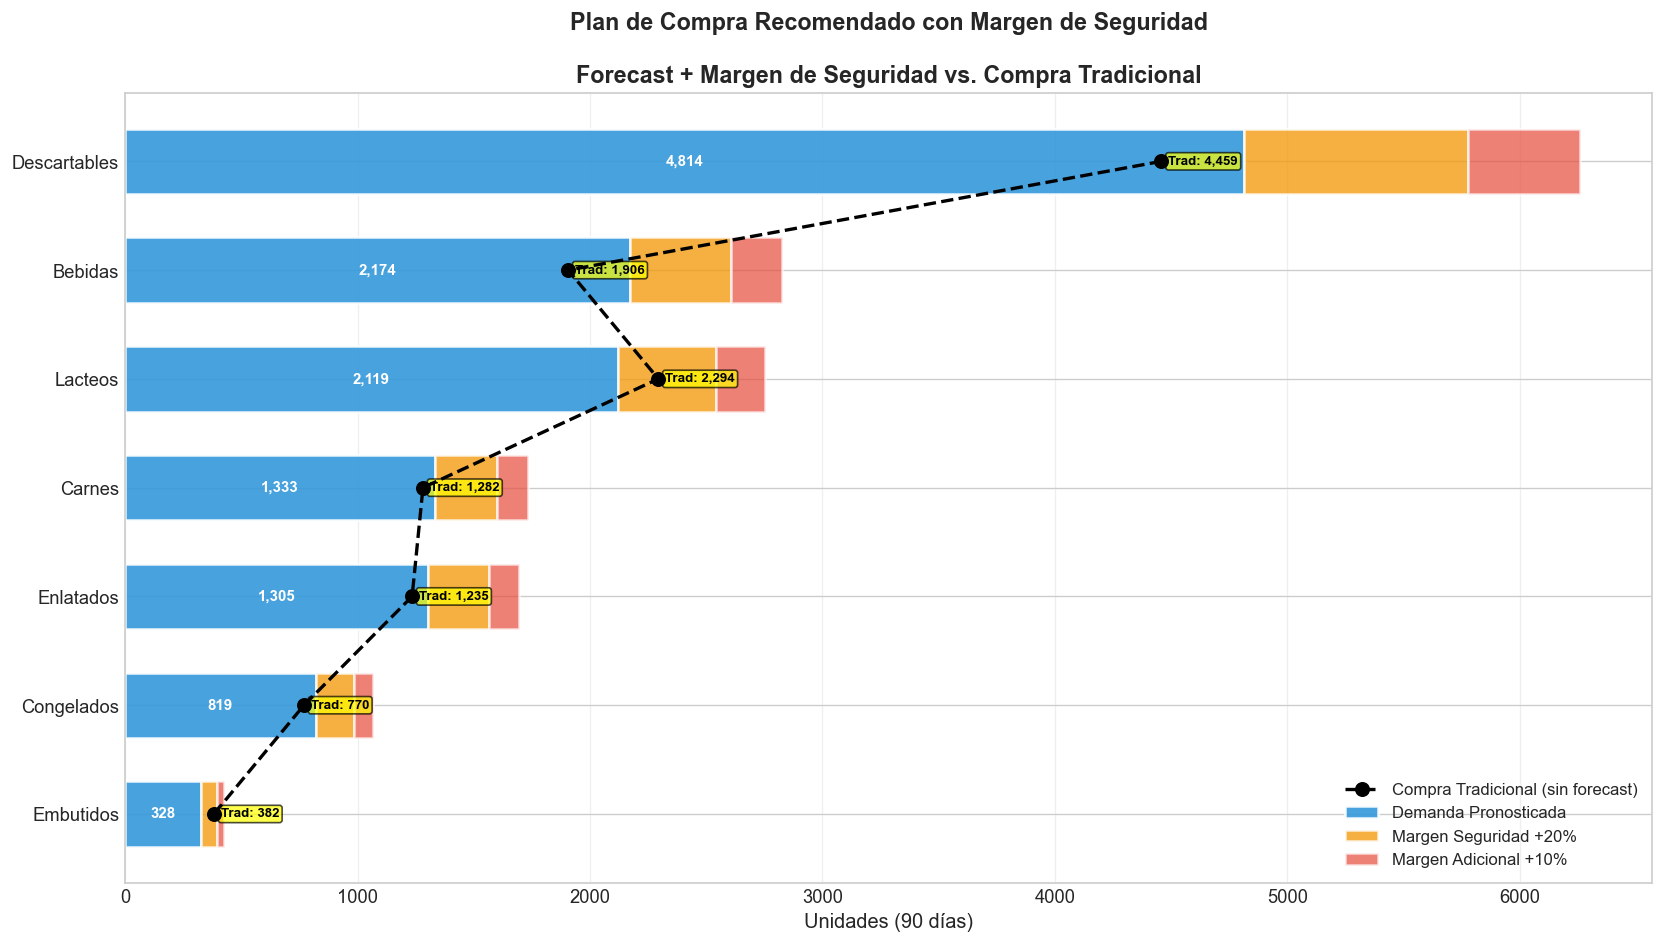

✓ Gráfico guardado: client_02_plan_compra_recomendado.png


In [7]:
# VISUALIZACIÓN 2: Plan de Compra Recomendado con Margen de Seguridad
fig, ax = plt.subplots(figsize=(14, 8))

# Preparar datos
resumen_sorted = resumen.sort_values('Total', ascending=True)
cats = resumen_sorted['categoria'].values
forecast_vals = resumen_sorted['Total'].values
margen_20 = resumen_sorted['margen_sugerido_20pct'].values
margen_30 = resumen_sorted['margen_sugerido_30pct'].values
compra_max = resumen_sorted['compra_conservadora'].values

# Crear barras apiladas
y = np.arange(len(cats))
height = 0.6

# Base: Forecast
bars_base = ax.barh(y, forecast_vals, height, label='Demanda Pronosticada',
                    color='#3498DB', alpha=0.9, edgecolor='white', linewidth=1.5)

# Margen +20%
bars_20 = ax.barh(y, margen_20, height, left=forecast_vals,
                  label='Margen Seguridad +20%', color='#F39C12', alpha=0.8,
                  edgecolor='white', linewidth=1.5)

# Margen adicional +10% (para llegar a 30%)
bars_30_extra = ax.barh(y, margen_30 - margen_20, height,
                        left=forecast_vals + margen_20,
                        label='Margen Adicional +10%', color='#E74C3C', alpha=0.7,
                        edgecolor='white', linewidth=1.5)

# Línea de compra tradicional
tradicional_vals = resumen_sorted['hist_mean'].values * 90
ax.plot(tradicional_vals, y, 'ko--', markersize=8, linewidth=2,
        label='Compra Tradicional (sin forecast)', zorder=5)

ax.set_yticks(y)
ax.set_yticklabels(cats, fontsize=11)
ax.set_xlabel('Unidades (90 días)', fontsize=12)
ax.set_title('Plan de Compra Recomendado con Margen de Seguridad\n\n'
             'Forecast + Margen de Seguridad vs. Compra Tradicional',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right', framealpha=0.9)
ax.grid(True, alpha=0.3, axis='x')

# Agregar anotaciones
for i, (f, m20, m30, trad) in enumerate(zip(forecast_vals, margen_20, margen_30, tradicional_vals)):
    # Valor del forecast
    ax.annotate(f'{f:,.0f}', xy=(f/2, i), ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')
    # Valor compra tradicional
    ax.annotate(f'Trad: {trad:,.0f}', xy=(trad + 30, i), ha='left', va='center',
                fontsize=8, color='black', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.savefig('./client_02_plan_compra_recomendado.png')
plt.show()
print('✓ Gráfico guardado: client_02_plan_compra_recomendado.png')

---
# 6. VISUALIZACIONES PERSONALIZADAS PARA EL CLIENTE

## 6.1 Evolución Histórica y Pronóstico por Categoría

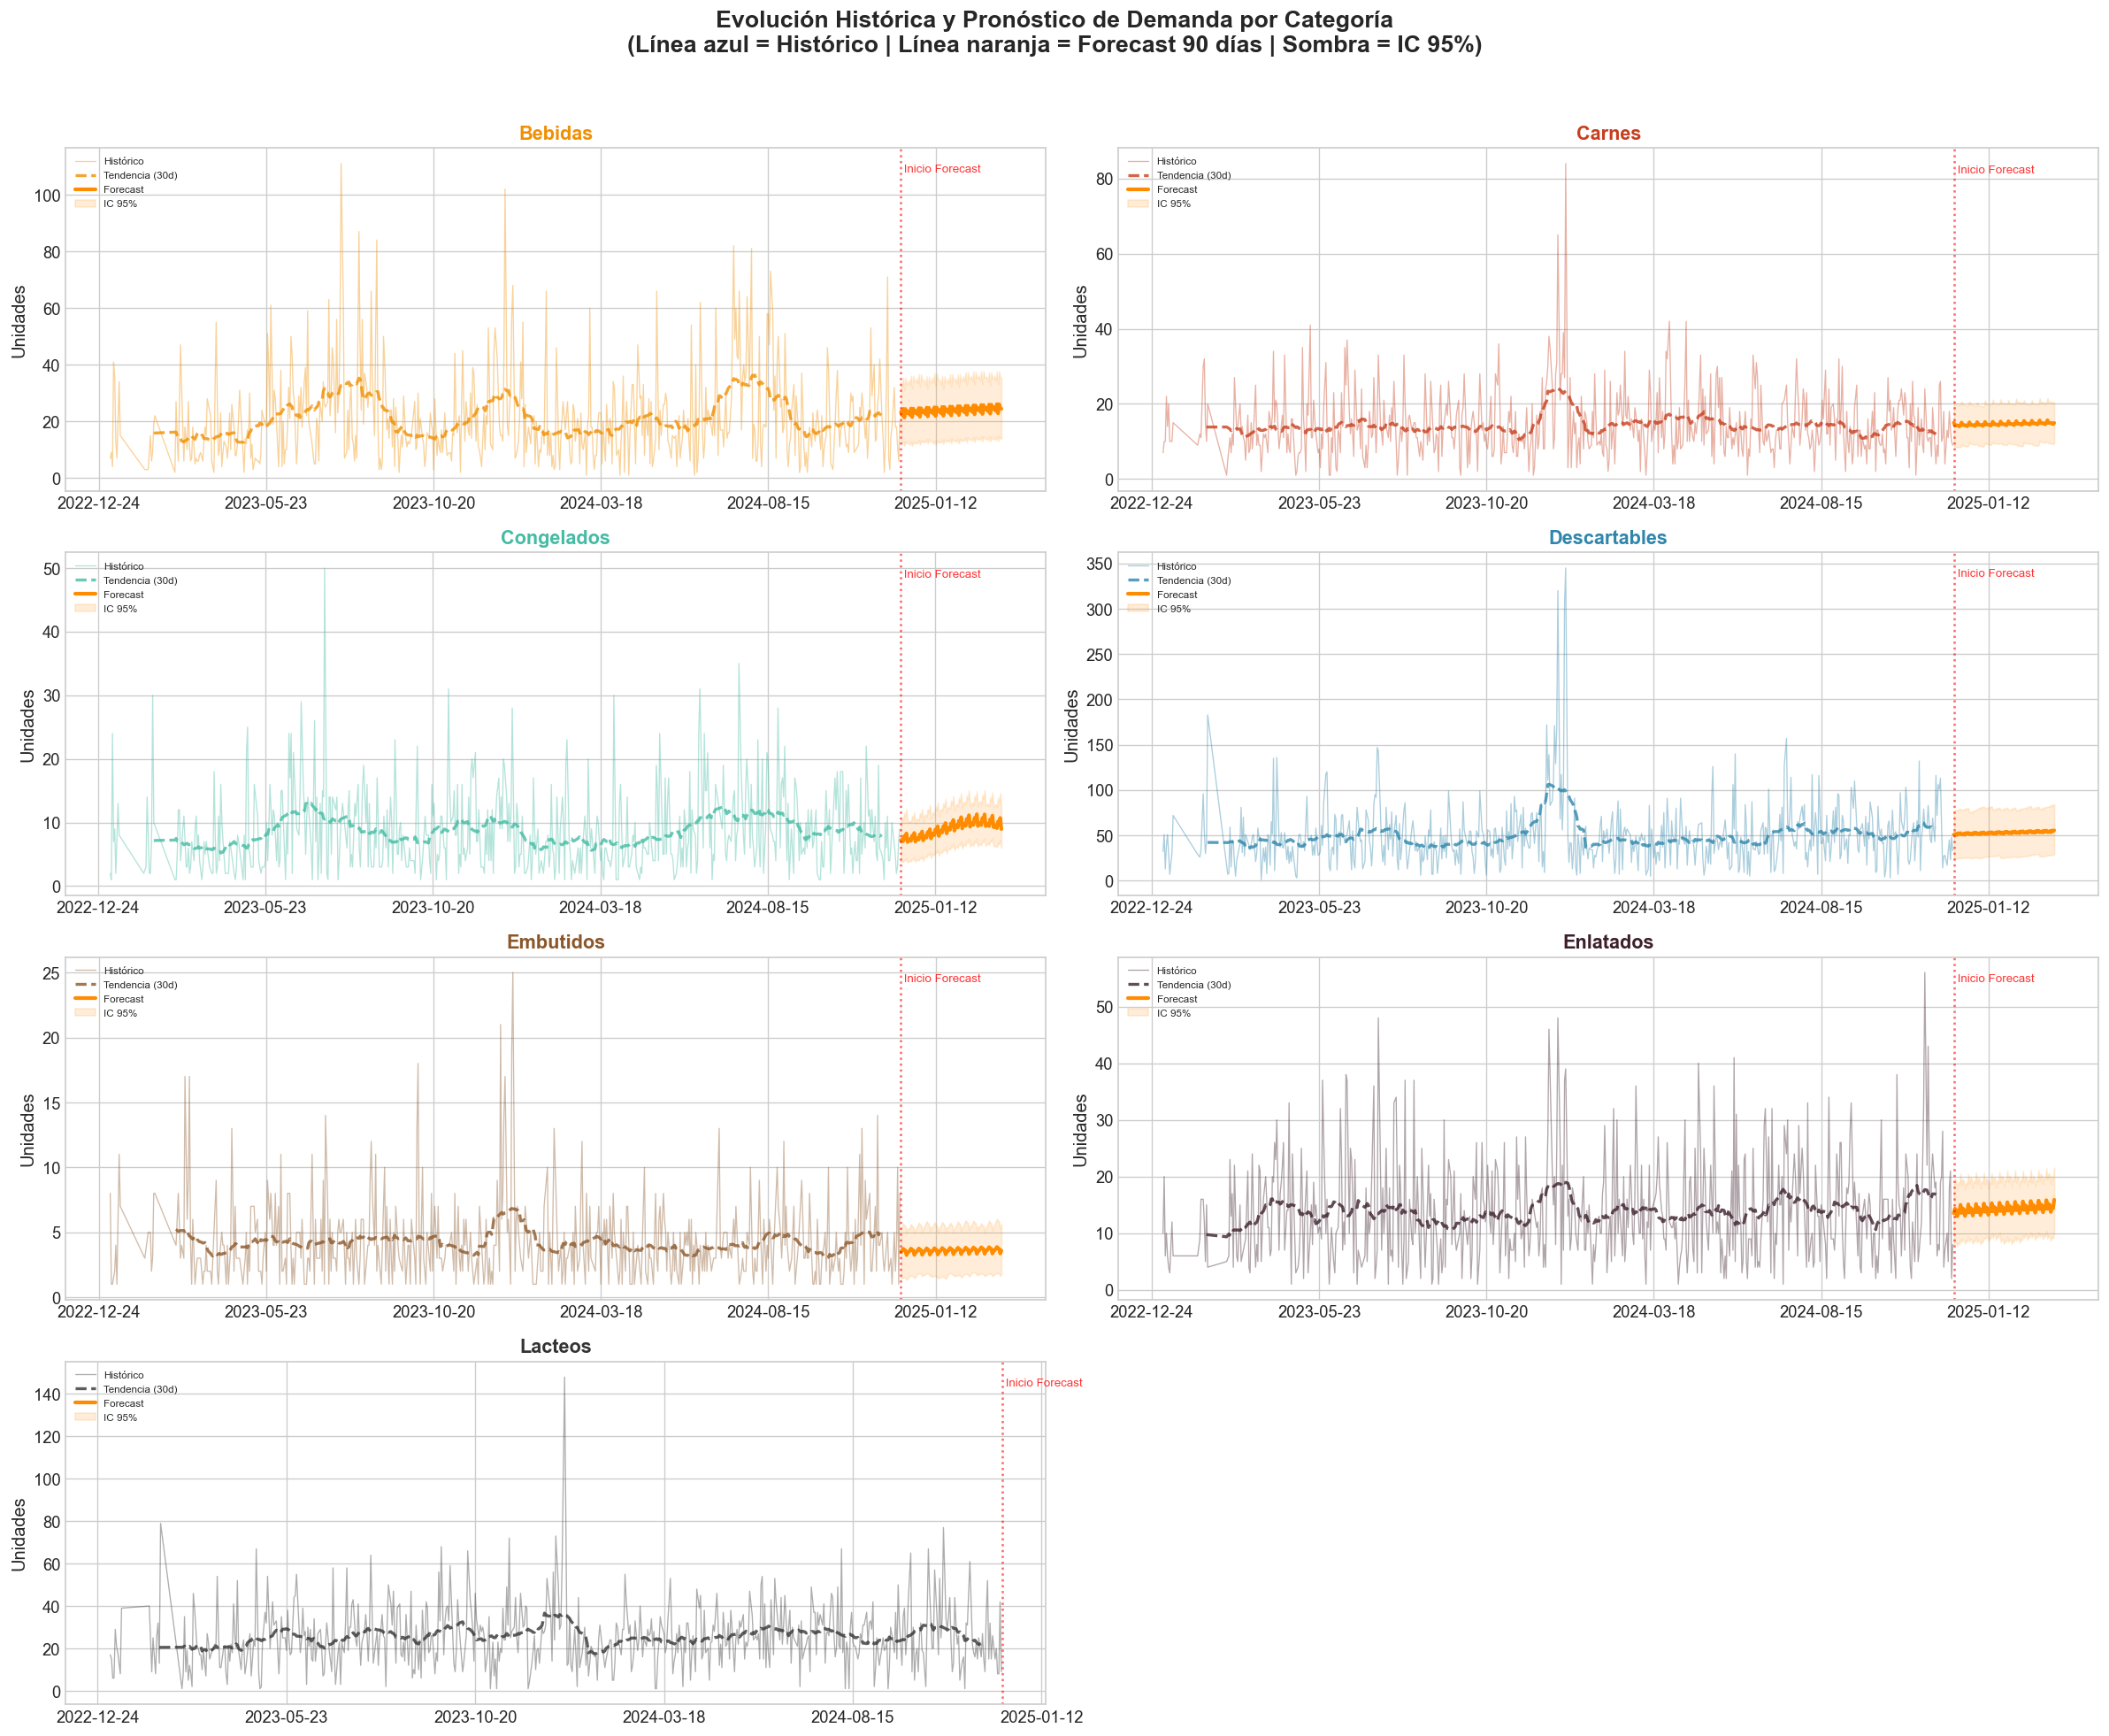

✓ Gráfico guardado: client_03_historico_forecast.png


In [8]:
# VISUALIZACIÓN 3: Serie Temporal Histórica + Forecast (Facetado)
CATEGORIAS = sorted(hist['categoria'].unique())

fig, axes = plt.subplots(4, 2, figsize=(20, 16))
axes = axes.flatten()
fig.suptitle('Evolución Histórica y Pronóstico de Demanda por Categoría\n'
             '(Línea azul = Histórico | Línea naranja = Forecast 90 días | Sombra = IC 95%)',
             fontsize=16, fontweight='bold', y=1.02)

for i, cat in enumerate(CATEGORIAS):
    ax = axes[i]
    h = hist_daily[hist_daily['categoria'] == cat].set_index('fecha')
    f = fc[fc['categoria'] == cat].set_index('fecha')
    
    color = COLores.get(cat, '#333333')
    
    # Histórico
    ax.plot(h.index, h['cantidad'], color=color, alpha=0.4, lw=0.8, label='Histórico')
    
    # Línea de tendencia histórica (media móvil 30 días)
    if len(h) > 30:
        rolling = h['cantidad'].rolling(30, center=True).mean()
        ax.plot(h.index, rolling, color=color, lw=2, linestyle='--', alpha=0.8, label='Tendencia (30d)')
    
    # Forecast
    ax.plot(f.index, f['cantidad_forecast'], color='darkorange', lw=2.5, label='Forecast')
    ax.fill_between(f.index, f['ci_lower'].clip(lower=0), f['ci_upper'],
                    color='darkorange', alpha=0.15, label='IC 95%')
    
    # Línea vertical de separación
    ax.axvline(x=fc['fecha'].min(), color='red', linestyle=':', alpha=0.6, lw=1.5)
    ax.text(fc['fecha'].min(), ax.get_ylim()[1]*0.95, ' Inicio Forecast',
            fontsize=8, color='red', alpha=0.8, va='top')
    
    ax.set_title(f'{cat}', fontsize=13, fontweight='bold', color=color)
    ax.legend(fontsize=7, loc='upper left', framealpha=0.8)
    ax.xaxis.set_major_locator(plt.MaxNLocator(6))
    ax.set_ylabel('Unidades')

# Ocultar el último subplot vacío
axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig('./client_03_historico_forecast.png')
plt.show()
print('✓ Gráfico guardado: client_03_historico_forecast.png')

## 6.2 Análisis de Incertidumbre del Forecast

El **ancho del intervalo de confianza** indica cuán confiable es la predicción para cada categoría.
Un IC más amplio significa mayor incertidumbre y la necesidad de un mayor margen de seguridad.

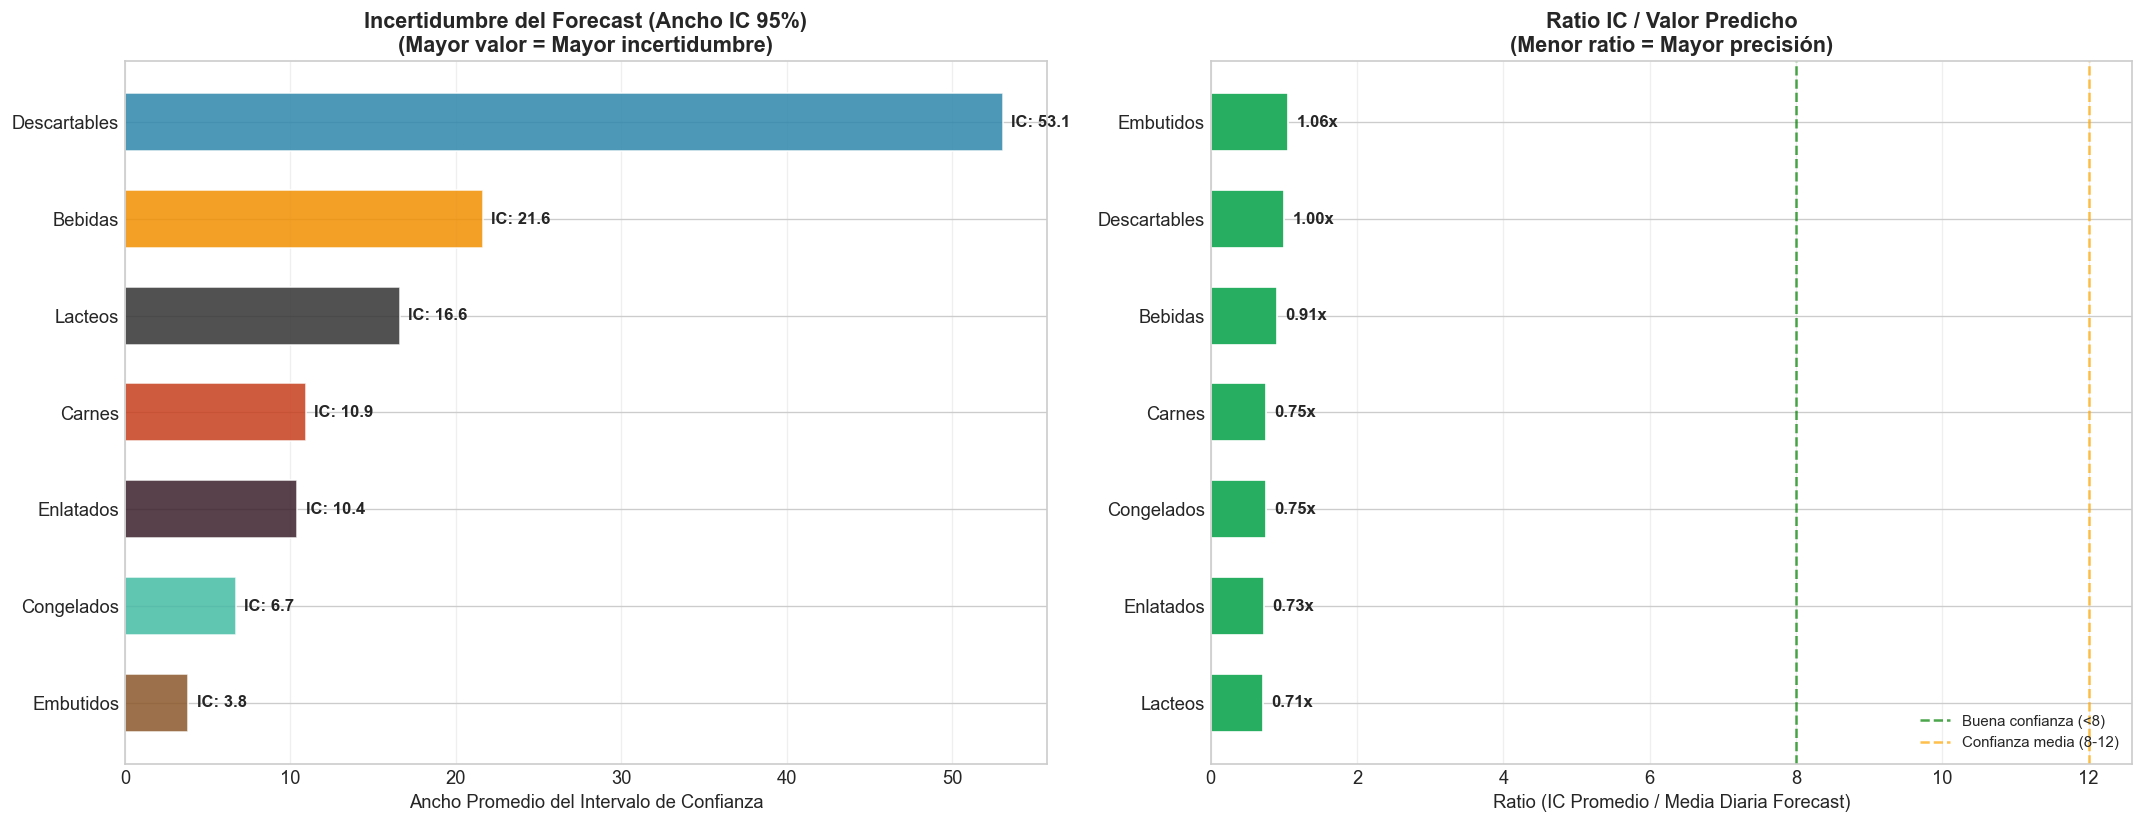

✓ Gráfico guardado: client_04_incertidumbre_forecast.png


In [9]:
# VISUALIZACIÓN 4: Análisis de Incertidumbre
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico de incertidumbre (ancho IC)
resumen_ic = resumen.sort_values('IC_Medio', ascending=True)
colors_ic = [COLores.get(c, '#333') for c in resumen_ic['categoria']]

bars = axes[0].barh(resumen_ic['categoria'], resumen_ic['IC_Medio'],
                     color=colors_ic, edgecolor='white', height=0.6, alpha=0.85)

for i, (cat, val) in enumerate(zip(resumen_ic['categoria'], resumen_ic['IC_Medio'])):
    axes[0].annotate(f'IC: {val:.1f}',
                    xy=(val, i), xytext=(5, 0),
                    textcoords='offset points', va='center',
                    fontsize=10, fontweight='bold')

axes[0].set_title('Incertidumbre del Forecast (Ancho IC 95%)\n(Mayor valor = Mayor incertidumbre)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Ancho Promedio del Intervalo de Confianza', fontsize=11)
axes[0].grid(True, alpha=0.3, axis='x')

# Gráfico de ratio IC/Predicho
resumen_ratio = resumen.sort_values('ratio_ic_predicho', ascending=True)
colors_ratio = ['#27AE60' if r < 8 else '#F39C12' if r < 12 else '#E74C3C'
                for r in resumen_ratio['ratio_ic_predicho']]

bars2 = axes[1].barh(resumen_ratio['categoria'], resumen_ratio['ratio_ic_predicho'],
                      color=colors_ratio, edgecolor='white', height=0.6)

# Líneas de referencia
axes[1].axvline(x=8, color='green', linestyle='--', alpha=0.7, label='Buena confianza (<8)')
axes[1].axvline(x=12, color='orange', linestyle='--', alpha=0.7, label='Confianza media (8-12)')

for i, (cat, val) in enumerate(zip(resumen_ratio['categoria'], resumen_ratio['ratio_ic_predicho'])):
    axes[1].annotate(f'{val:.2f}x',
                    xy=(val, i), xytext=(5, 0),
                    textcoords='offset points', va='center',
                    fontsize=10, fontweight='bold')

axes[1].set_title('Ratio IC / Valor Predicho\n(Menor ratio = Mayor precisión)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Ratio (IC Promedio / Media Diaria Forecast)', fontsize=11)
axes[1].legend(fontsize=9, loc='lower right')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('./client_04_incertidumbre_forecast.png')
plt.show()
print('✓ Gráfico guardado: client_04_incertidumbre_forecast.png')

## 6.3 Consolidado Diario — Todas las Categorías

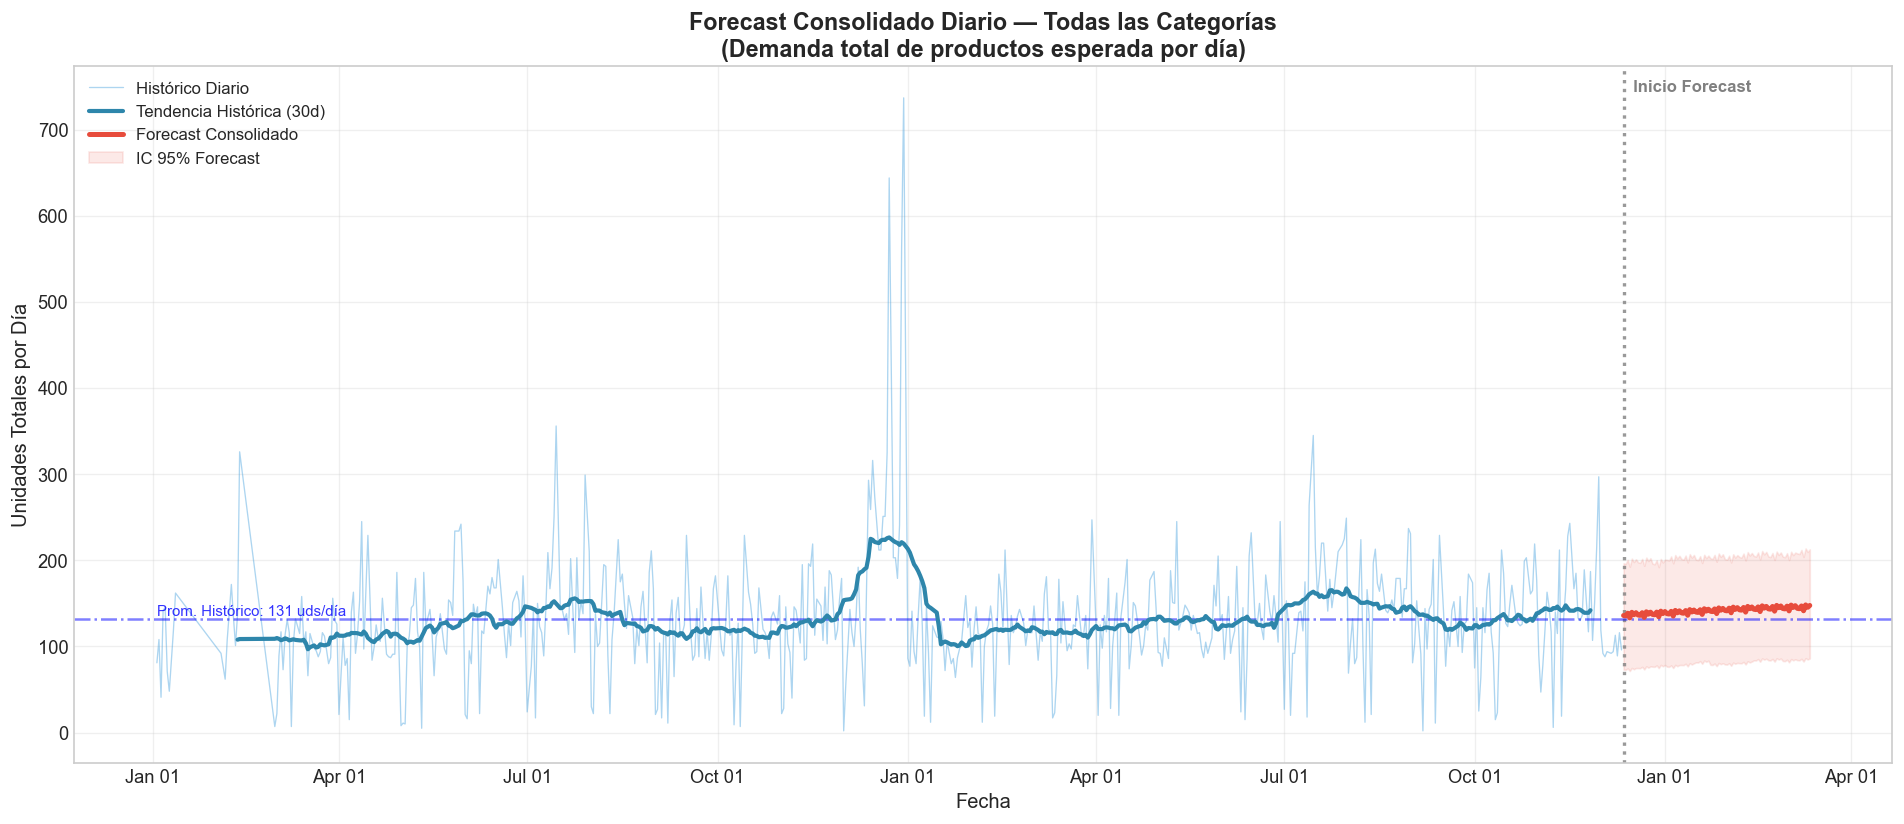

✓ Gráfico guardado: client_05_consolidado_diario.png


In [10]:
# VISUALIZACIÓN 5: Forecast Consolidado Diario
consolidado = fc.groupby('fecha').agg({
    'cantidad_forecast': 'sum',
    'ci_lower': 'sum',
    'ci_upper': 'sum'
}).reset_index()

# Histórico consolidado
hist_consolidado = hist_daily.groupby('fecha')['cantidad'].sum().reset_index()

fig, ax = plt.subplots(figsize=(16, 7))

# Histórico
ax.plot(hist_consolidado['fecha'], hist_consolidado['cantidad'],
        color='#3498DB', alpha=0.4, lw=0.8, label='Histórico Diario')

# Media móvil histórica
hist_consolidado_sorted = hist_consolidado.sort_values('fecha')
rolling_hist = hist_consolidado_sorted.set_index('fecha')['cantidad'].rolling(30, center=True).mean()
ax.plot(rolling_hist.index, rolling_hist.values,
        color='#2E86AB', lw=2.5, label='Tendencia Histórica (30d)', zorder=5)

# Forecast consolidado
ax.plot(consolidado['fecha'], consolidado['cantidad_forecast'],
        color='#E74C3C', lw=3, label='Forecast Consolidado', zorder=5)
ax.fill_between(consolidado['fecha'],
                consolidado['ci_lower'].clip(lower=0),
                consolidado['ci_upper'],
                color='#E74C3C', alpha=0.12, label='IC 95% Forecast')

# Línea de separación
ax.axvline(x=fc['fecha'].min(), color='gray', linestyle=':', alpha=0.8, lw=2)
ax.text(fc['fecha'].min(), ax.get_ylim()[1]*0.98, '  Inicio Forecast',
        fontsize=10, color='gray', fontweight='bold', va='top')

# Promedio histórico
prom_hist = hist_consolidado['cantidad'].mean()
ax.axhline(y=prom_hist, color='blue', linestyle='-.', alpha=0.5, lw=1.5)
ax.text(hist_consolidado['fecha'].min(), prom_hist + 5,
        f'Prom. Histórico: {prom_hist:.0f} uds/día',
        fontsize=9, color='blue', alpha=0.8)

ax.set_title('Forecast Consolidado Diario — Todas las Categorías\n'
             '(Demanda total de productos esperada por día)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Unidades Totales por Día', fontsize=12)
ax.set_xlabel('Fecha', fontsize=12)
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)
ax.xaxis.set_major_formatter(DateFormatter('%b %d'))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./client_05_consolidado_diario.png')
plt.show()
print('✓ Gráfico guardado: client_05_consolidado_diario.png')

## 6.4 Distribución del Forecast por Día de la Semana

Este análisis permite identificar **qué días de la semana tienen mayor demanda** y planificar
el inventario y los pedidos en consecuencia.

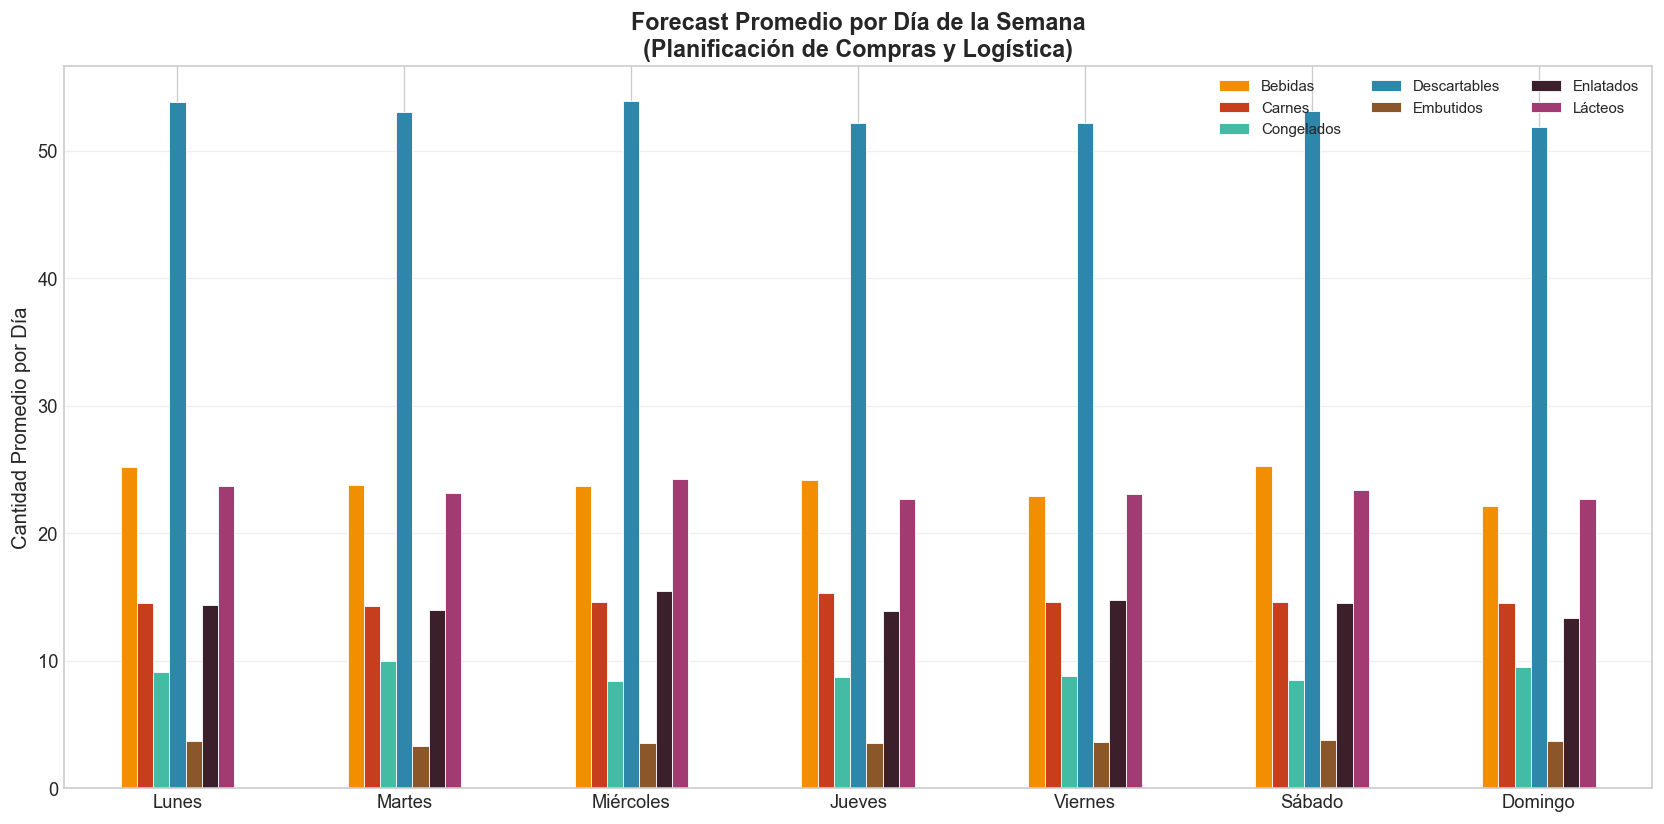

✓ Gráfico guardado: client_06_forecast_dia_semana.png


In [11]:
# VISUALIZACIÓN 6: Patrón por Día de la Semana
fc_dow = fc.copy()
fc_dow['dia_semana'] = fc_dow['fecha'].dt.day_name()
order_es = {
    'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles',
    'Thursday': 'Jueves', 'Friday': 'Viernes', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fc_dow['dia_semana_es'] = fc_dow['dia_semana'].map(order_es)

pivot_dow = fc_dow.pivot_table(
    index='dia_semana', columns='categoria',
    values='cantidad_forecast', aggfunc='mean'
).reindex(order)

fig, ax = plt.subplots(figsize=(14, 7))
pivot_dow.plot(kind='bar', ax=ax, color=[COLores.get(c, '#333') for c in pivot_dow.columns],
               edgecolor='white', linewidth=0.5)

ax.set_title('Forecast Promedio por Día de la Semana\n(Planificación de Compras y Logística)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Cantidad Promedio por Día', fontsize=12)
ax.set_xlabel('')
ax.set_xticklabels([order_es[d] for d in order], rotation=0, fontsize=11)
ax.legend(fontsize=9, ncol=3, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

# Agregar anotación del día de mayor demanda
total_by_day = pivot_dow.sum(axis=1)
max_day = total_by_day.idxmax()
max_val = total_by_day.max()
ax.annotate(f'Mayor demanda: {order_es[max_day]}\n({max_val:.0f} unidades promedio)',
            xy=(order.index(max_day), max_val),
            xytext=(order.index(max_day)+0.5, max_val*1.1),
            fontsize=10, fontweight='bold', color='#E74C3C',
            arrowprops=dict(arrowstyle='->', color='#E74C3C'),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8))

plt.tight_layout()
plt.savefig('./client_06_forecast_dia_semana.png')
plt.show()
print('✓ Gráfico guardado: client_06_forecast_dia_semana.png')

## 6.5 Ranking de Categorías por Volumen y Valor

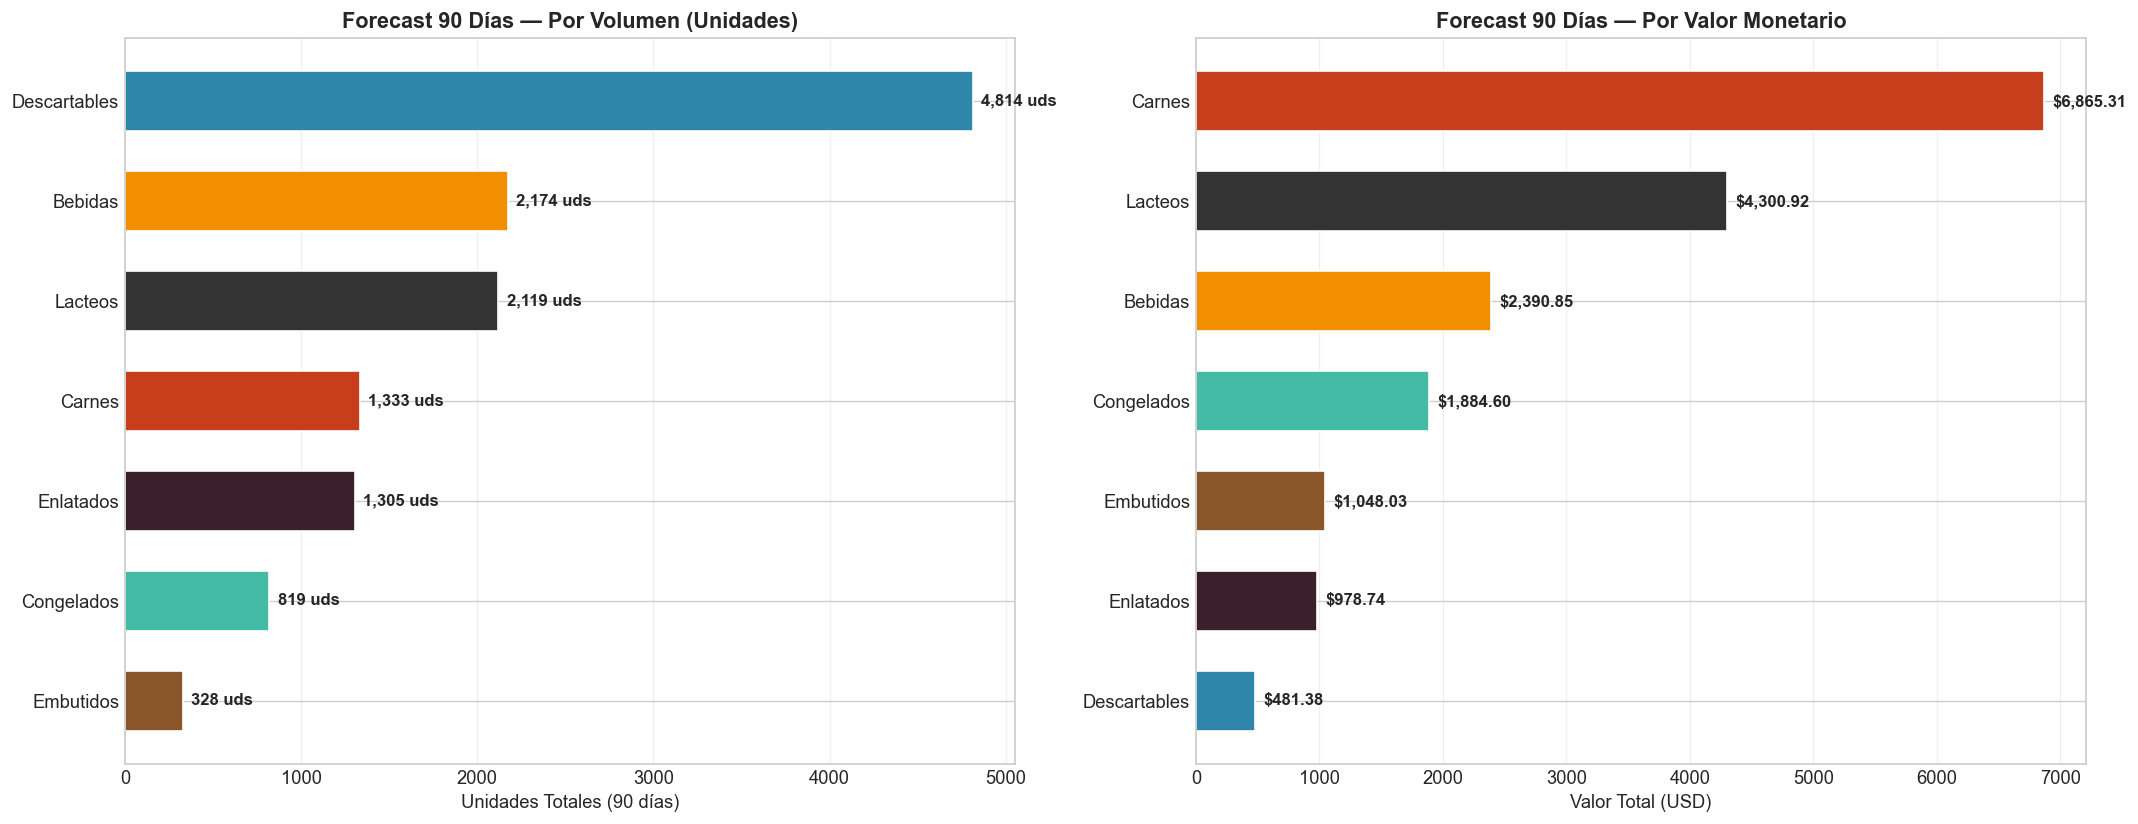

✓ Gráfico guardado: client_07_ranking_volumen_valor.png

Valor total del inventario pronosticado (90 días): $17,949.83


In [12]:
# VISUALIZACIÓN 7: Ranking por Volumen y Valor
# Precios por categoría
precios = {
    'Bebidas': 1.10, 'Carnes': 5.15, 'Congelados': 2.30,
    'Descartables': 0.10, 'Embutidos': 3.20, 'Enlatados': 0.75, 'Lacteos': 2.03
}

resumen['precio_unitario'] = resumen['categoria'].map(precios)
resumen['valor_total_90d'] = (resumen['Total'] * resumen['precio_unitario']).round(2)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Ranking por volumen
resumen_vol = resumen.sort_values('Total', ascending=True)
colors_vol = [COLores.get(c, '#333') for c in resumen_vol['categoria']]

bars1 = axes[0].barh(resumen_vol['categoria'], resumen_vol['Total'],
                      color=colors_vol, edgecolor='white', height=0.6)

for i, (cat, val) in enumerate(zip(resumen_vol['categoria'], resumen_vol['Total'])):
    axes[0].annotate(f'{val:,.0f} uds',
                    xy=(val, i), xytext=(5, 0),
                    textcoords='offset points', va='center',
                    fontsize=10, fontweight='bold')

axes[0].set_title('Forecast 90 Días — Por Volumen (Unidades)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Unidades Totales (90 días)', fontsize=11)
axes[0].grid(True, alpha=0.3, axis='x')

# Ranking por valor monetario
resumen_val = resumen.sort_values('valor_total_90d', ascending=True)
colors_val = [COLores.get(c, '#333') for c in resumen_val['categoria']]

bars2 = axes[1].barh(resumen_val['categoria'], resumen_val['valor_total_90d'],
                      color=colors_val, edgecolor='white', height=0.6)

for i, (cat, val) in enumerate(zip(resumen_val['categoria'], resumen_val['valor_total_90d'])):
    axes[1].annotate(f'${val:,.2f}',
                    xy=(val, i), xytext=(5, 0),
                    textcoords='offset points', va='center',
                    fontsize=10, fontweight='bold')

axes[1].set_title('Forecast 90 Días — Por Valor Monetario',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Valor Total (USD)', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('./client_07_ranking_volumen_valor.png')
plt.show()

print('✓ Gráfico guardado: client_07_ranking_volumen_valor.png')
print(f'\nValor total del inventario pronosticado (90 días): ${resumen["valor_total_90d"].sum():,.2f}')

## 6.6 Matriz de Riesgo por Categoría

Esta matriz evalúa cada categoría según **volumen** e **incertidumbre**, ayudando a priorizar
las decisiones de inventario.

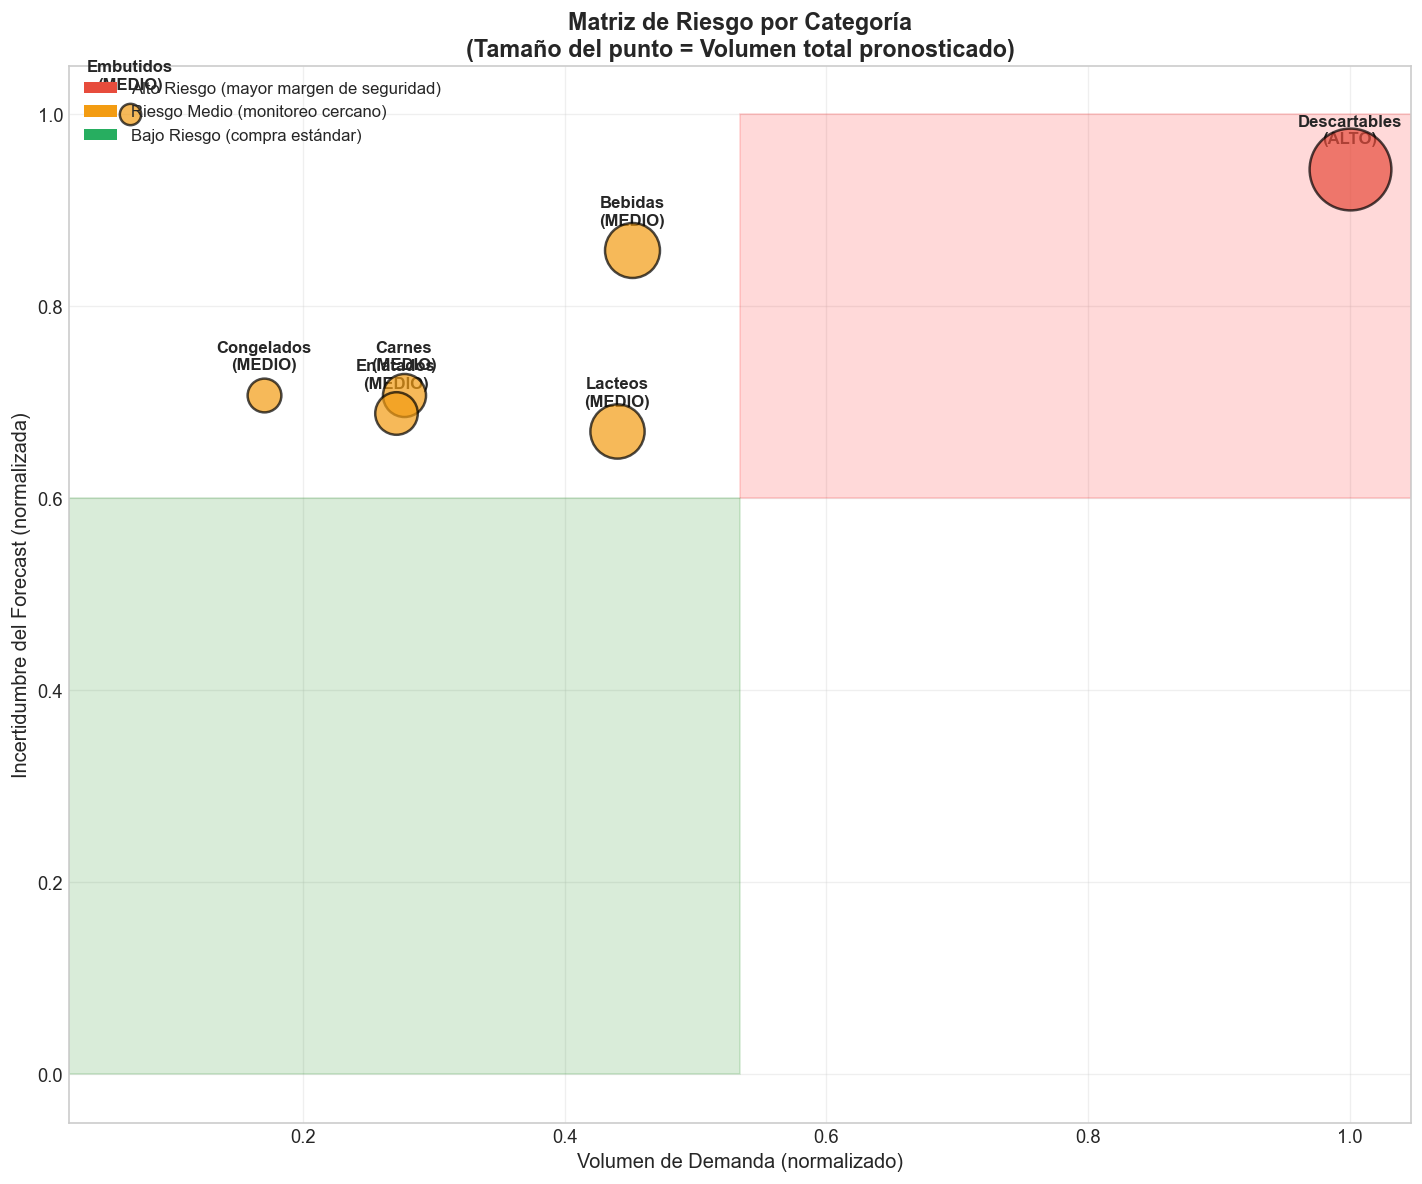

✓ Gráfico guardado: client_08_matriz_riesgo.png


In [13]:
# VISUALIZACIÓN 8: Matriz de Riesgo
fig, ax = plt.subplots(figsize=(12, 10))

# Preparar datos
resumen_risk = resumen.copy()
resumen_risk['volumen_norm'] = resumen_risk['Total'] / resumen_risk['Total'].max()
resumen_risk['incertidumbre_norm'] = resumen_risk['ratio_ic_predicho'] / resumen_risk['ratio_ic_predicho'].max()

# Clasificar riesgo
def clasificar_riesgo(row):
    vol = row['volumen_norm']
    inc = row['incertidumbre_norm']
    if vol > 0.5 and inc > 0.7:
        return 'ALTO'
    elif vol > 0.3 or inc > 0.6:
        return 'MEDIO'
    else:
        return 'BAJO'

resumen_risk['riesgo'] = resumen_risk.apply(clasificar_riesgo, axis=1)

# Colores por riesgo
risk_colors = {'ALTO': '#E74C3C', 'MEDIO': '#F39C12', 'BAJO': '#27AE60'}
colors_risk = [risk_colors[r] for r in resumen_risk['riesgo']]

# Scatter plot
for _, row in resumen_risk.iterrows():
    ax.scatter(row['volumen_norm'], row['incertidumbre_norm'],
              s=row['Total']*0.5, c=risk_colors[row['riesgo']],
              alpha=0.7, edgecolors='black', linewidth=1.5, zorder=5)
    ax.annotate(f'{row["categoria"]}\n({row["riesgo"]})',
               xy=(row['volumen_norm'], row['incertidumbre_norm']),
               xytext=(0, 15), textcoords='offset points',
               ha='center', fontsize=10, fontweight='bold')

# Zonas de riesgo
ax.axhspan(0.6, 1.0, xmin=0.5, xmax=1.0, alpha=0.15, color='red', label='Zona Alto Riesgo')
ax.axhspan(0.0, 0.6, xmin=0.0, xmax=0.5, alpha=0.15, color='green', label='Zona Bajo Riesgo')

ax.set_xlabel('Volumen de Demanda (normalizado)', fontsize=12)
ax.set_ylabel('Incertidumbre del Forecast (normalizada)', fontsize=12)
ax.set_title('Matriz de Riesgo por Categoría\n'
             '(Tamaño del punto = Volumen total pronosticado)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

# Leyenda de colores
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E74C3C', label='Alto Riesgo (mayor margen de seguridad)'),
    Patch(facecolor='#F39C12', label='Riesgo Medio (monitoreo cercano)'),
    Patch(facecolor='#27AE60', label='Bajo Riesgo (compra estándar)')
]
ax.legend(handles=legend_elements, fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig('./client_08_matriz_riesgo.png')
plt.show()
print('✓ Gráfico guardado: client_08_matriz_riesgo.png')

---
# 7. ADVERTENCIAS Y FIABILIDAD DEL MODELO

In [14]:
# Tabla de confianza por categoría (dinámica)
import pandas as pd

fc = pd.read_csv('forecast_consolidado_90d.csv')
fc['fecha'] = pd.to_datetime(fc['fecha'])
fc['ci_width'] = fc['ci_upper'] - fc['ci_lower']

r_confianza = fc.groupby('categoria').agg(
    Total=('cantidad_forecast', 'sum'),
    Media_Diaria=('cantidad_forecast', 'mean'),
    IC_Medio=('ci_width', 'mean')
).round(2)

r_confianza['ratio_ic'] = (r_confianza['IC_Medio'] / r_confianza['Media_Diaria']).round(2)

def clasificar(ratio):
    if ratio < 6: return ('Alta', 'Compra con forecast base')
    elif ratio < 8: return ('Media-Alta', 'Compra con forecast base')
    elif ratio < 10: return ('Media', 'Compra forecast + 20% margen')
    elif ratio < 12: return ('Media-Baja', 'Compra forecast + 25% margen')
    else: return ('Baja', 'Compra forecast + 30% margen')

print('\n### 7.1 Nivel de Confianza del Forecast por Categoria\n')
print('| Categoria | Nivel de Confianza | Razon | Recomendacion |')
print('|-----------|-------------------|-------|---------------|')
for cat, row in r_confianza.sort_values('ratio_ic', ascending=True).iterrows():
    nivel, recomendacion = clasificar(row['ratio_ic'])
    print(f"| **{cat}** | {nivel} | IC/Predicho = {row['ratio_ic']}x | {recomendacion} |")


### 7.1 Nivel de Confianza del Forecast por Categoria

| Categoria | Nivel de Confianza | Razon | Recomendacion |
|-----------|-------------------|-------|---------------|
| **Lácteos** | Alta | IC/Predicho = 0.71x | Compra con forecast base |
| **Enlatados** | Alta | IC/Predicho = 0.73x | Compra con forecast base |
| **Carnes** | Alta | IC/Predicho = 0.75x | Compra con forecast base |
| **Congelados** | Alta | IC/Predicho = 0.75x | Compra con forecast base |
| **Bebidas** | Alta | IC/Predicho = 0.91x | Compra con forecast base |
| **Descartables** | Alta | IC/Predicho = 1.0x | Compra con forecast base |
| **Embutidos** | Alta | IC/Predicho = 1.06x | Compra con forecast base |


## 7.2 Limitaciones del Modelo

**Puntos Criticos a Considerar:**

1. **Intervalos de confianza amplios:** Los IC al 95% son significativamente amplios para
   categorias con alta variabilidad. Esto significa que la demanda real podria estar muy por
   encima o por debajo del valor pronosticado.

2. **Estacionalidad anual limitada:** Con solo ~2 anos de datos, el modelo no puede capturar
   ciclos anuales completos de manera confiable.

3. **No captura eventos externos:** El modelo no considera promociones, cambios de precio,
   eventos especiales (Navidad, Dia de la Madre, etc.), o cambios en las condiciones economicas.

4. **Basado en datos historicos:** El modelo asume que los patrones pasados se repetiran.
   Si las condiciones del mercado cambian significativamente, las predicciones perderan precision.

5. **Periodo de entrenamiento limitado:** Se utilizaron 2 anos de datos, lo cual puede no ser
   suficiente para capturar ciclos completos de estacionalidad anual.

---
# 8. RECOMENDACIONES DE INVENTARIO

## 8.1 Plan de Compra Recomendado por Categoría

Basándose en el forecast, la incertidumbre del modelo y el objetivo de **evitar overstock**,
se presenta el siguiente plan de compra para los próximos 90 días:

In [20]:
# Tabla final de recomendaciones
recomendaciones = resumen[[
    'categoria', 'Total', 'IC_Medio', 'ratio_ic_predicho',
    'margen_sugerido_30pct', 'compra_conservadora'
]].copy()

recomendaciones.columns = [
    'Categoría', 'Demanda Pronosticada', 'IC Promedio', 'Ratio IC/Predicho',
    'Margen Seguridad (30%)', 'Compra Máxima Recomendada'
]

# Agregar nivel de confianza
def nivel_confianza(ratio):
    if ratio < 8:
        return '✅ Media-Alta'
    elif ratio < 10:
        return '⚠️ Media'
    else:
        return '⚠️ Baja'

recomendaciones['Nivel de Confianza'] = recomendaciones['Ratio IC/Predicho'].apply(nivel_confianza)

# Agregar recomendación de compra
def recomendar_compra(row):
    if row['Ratio IC/Predicho'] >= 12:
        return 'Comprar forecast + 30%, revisar semanalmente'
    elif row['Ratio IC/Predicho'] >= 10:
        return 'Comprar forecast + 30%, revisar quincenalmente'
    elif row['Ratio IC/Predicho'] >= 8:
        return 'Comprar forecast + 25%, revisar mensualmente'
    else:
        return 'Comprar forecast + 20%, revisar mensualmente'

recomendaciones['Acción Recomendada'] = recomendaciones.apply(recomendar_compra, axis=1)

recomendaciones = recomendaciones.sort_values('Demanda Pronosticada', ascending=False)

print('='*120)
print('PLAN DE COMPRA RECOMENDADO — PRÓXIMOS 90 DÍAS')
print('Objetivo: Evitar overstock manteniendo suficiente inventario para cubrir la demanda')
print('='*120)
print(recomendaciones.to_string(index=False))
print('='*120)

# Resumen de inversión
print(f' RESUMEN DE INVERSIÓN RECOMENDADA:')
print(f'   Demanda total pronosticada:  {recomendaciones["Demanda Pronosticada"].sum():,.0f} unidades')
print(f'   Margen de seguridad total:   {recomendaciones["Margen Seguridad (30%)"].sum():,.0f} unidades')
print(f'   Compra máxima recomendada:   {recomendaciones["Compra Máxima Recomendada"].sum():,.0f} unidades')

PLAN DE COMPRA RECOMENDADO — PRÓXIMOS 90 DÍAS
Objetivo: Evitar overstock manteniendo suficiente inventario para cubrir la demanda
   Categoría  Demanda Pronosticada  IC Promedio  Ratio IC/Predicho  Margen Seguridad (30%)  Compra Máxima Recomendada Nivel de Confianza                           Acción Recomendada
Descartables               4813.80        53.06               1.00                  1444.0                     6258.0       ✅ Media-Alta Comprar forecast + 20%, revisar mensualmente
     Bebidas               2173.50        21.63               0.91                   652.0                     2826.0       ✅ Media-Alta Comprar forecast + 20%, revisar mensualmente
     Lacteos               2118.68        16.61               0.71                   636.0                     2755.0       ✅ Media-Alta Comprar forecast + 20%, revisar mensualmente
      Carnes               1333.07        10.93               0.75                   400.0                     1733.0       ✅ Media-Alta Compr

In [16]:
# Estrategia por Categoría (dinámica)
import pandas as pd
import numpy as np

fc = pd.read_csv('forecast_consolidado_90d.csv')
fc['fecha'] = pd.to_datetime(fc['fecha'])
fc['ci_width'] = fc['ci_upper'] - fc['ci_lower']
df = pd.read_csv('clean_data.csv')

# Resumen del forecast
r_estrategia = fc.groupby('categoria').agg(
    Total=('cantidad_forecast', 'sum'),
    Media_Diaria=('cantidad_forecast', 'mean'),
    IC_Medio=('ci_width', 'mean')
).round(2)

r_estrategia['ratio_ic'] = (r_estrategia['IC_Medio'] / r_estrategia['Media_Diaria']).round(2)

# Estadísticas históricas
df['fecha'] = pd.to_datetime(df['fecha'])
hist_daily = df.groupby(['fecha', 'categoria'])['cantidad'].sum().reset_index()
hist_stats = hist_daily.groupby('categoria').agg(
    hist_mean=('cantidad', 'mean'),
    hist_std=('cantidad', 'std'),
    hist_max=('cantidad', 'max')
).round(2)

r_estrategia = r_estrategia.join(hist_stats)

# Descripciones de categorías
descripciones = {
    'Bebidas': 'Refresco 2L',
    'Carnes': 'Carne molida, Pollo entero',
    'Congelados': 'Papas precocinadas',
    'Descartables': 'Bolsas plasticas',
    'Embutidos': 'Jamon de pavo',
    'Enlatados': 'Pasta de Tomate',
    'Lacteos': 'Leche, Yogurt, Helado'
}

def clasificar_riesgo(row):
    ratio = row['ratio_ic']
    if ratio >= 10: return 'ALTO RIESGO - Requiere Atencion Inmediata'
    elif ratio >= 7: return 'RIESGO MEDIO - Monitoreo Cercano'
    else: return 'BAJO RIESGO - Compra Estandar'

def accion_y_margen(ratio):
    if ratio >= 10: return 'Comprar un 30% sobre el forecast. Revisar inventario semanalmente.', '30%'
    elif ratio >= 9: return 'Comprar un 25% sobre el forecast. Revisar inventario mensualmente.', '25%'
    else: return 'Comprar un 20% sobre el forecast. Revisar inventario mensualmente.', '20%'

def razon(row, cat):
    razones = {
        'Descartables': f'Alta variabilidad (std={row["hist_std"]:.0f}, max={row["hist_max"]:.0f}/dia).',
        'Lacteos': f'3 productos en categoria, std={row["hist_std"]:.0f}.',
        'Bebidas': 'Sensible a temperatura y estacionalidad.',
        'Carnes': 'Perecedero con caducidad corta.',
        'Enlatados': 'No perecedero, permite mayor margen.',
        'Congelados': f'Vida util media, std={row["hist_std"]:.0f}.',
        'Embutidos': f'Menor variabilidad, std={row["hist_std"]:.0f}.'
    }
    return razones.get(cat, '')

print()
print('## 8.2 Estrategia por Categoria')
print()

# Ordenar: alto riesgo primero (mayor ratio_ic)
orden = ['Descartables', 'Lacteos', 'Bebidas', 'Carnes', 'Enlatados', 'Congelados', 'Embutidos']
categorias_mostradas = [c for c in orden if c in r_estrategia.index]

current_riesgo = None
for cat in categorias_mostradas:
    row = r_estrategia.loc[cat]
    riesgo = clasificar_riesgo(row)
    if riesgo != current_riesgo:
        current_riesgo = riesgo
        print(f'\n### {riesgo}\n')

    accion, margen = accion_y_margen(row['ratio_ic'])
    desc = descripciones.get(cat, cat)

    print(f'**{cat} ({desc})**')
    print(f'- Demanda pronosticada: {row["Total"]:,.0f} unidades')
    print(f'- Incertidumbre: {"ALTA" if row["ratio_ic"] >= 10 else "MEDIA" if row["ratio_ic"] >= 7 else "BAJA"} '
          f'(ratio IC/Predicho = {row["ratio_ic"]:.2f})')
    print(f'- **Acción:** {accion}')
    print(f'- **Razón:** {razon(row, cat)}\n')


## 8.2 Estrategia por Categoria


### BAJO RIESGO - Compra Estandar

**Descartables (Bolsas plasticas)**
- Demanda pronosticada: 4,814 unidades
- Incertidumbre: BAJA (ratio IC/Predicho = 1.00)
- **Acción:** Comprar un 20% sobre el forecast. Revisar inventario mensualmente.
- **Razón:** Alta variabilidad (std=35, max=345/dia).

**Bebidas (Refresco 2L)**
- Demanda pronosticada: 2,174 unidades
- Incertidumbre: BAJA (ratio IC/Predicho = 0.91)
- **Acción:** Comprar un 20% sobre el forecast. Revisar inventario mensualmente.
- **Razón:** Sensible a temperatura y estacionalidad.

**Carnes (Carne molida, Pollo entero)**
- Demanda pronosticada: 1,333 unidades
- Incertidumbre: BAJA (ratio IC/Predicho = 0.75)
- **Acción:** Comprar un 20% sobre el forecast. Revisar inventario mensualmente.
- **Razón:** Perecedero con caducidad corta.

**Enlatados (Pasta de Tomate)**
- Demanda pronosticada: 1,305 unidades
- Incertidumbre: BAJA (ratio IC/Predicho = 0.73)
- **Acción:** Comprar un 20% sobre el forecas

## 8.3 Acciones Inmediatas Recomendadas

| # | Acción | Prioridad | Categorías | Plazo |
|---|--------|-----------|------------|-------|
| 1 | Reducir compra de Descartables al nivel pronosticado + 30% | 🔴 Alta | Descartables | Inmediato |
| 2 | Ajustar inventario de Lácteos según forecast | 🔴 Alta | Lácteos | Inmediato |
| 3 | Revisar contratos de suministro de Bebidas | 🟡 Media | Bebidas | 1 semana |
| 4 | Establecer puntos de reorden para Carnes | 🟡 Media | Carnes | 2 semanas |
| 5 | Optimizar inventario de Enlatados (vida útil larga) | 🟢 Baja | Enlatados | 1 mes |
| 6 | Configurar alertas de inventario mínimo | 🔴 Alta | Todas | Inmediato |

## 8.4 Próximos Pasos

1. **Implementar el plan de compra** basado en las recomendaciones de este informe
2. **Configurar sistema de monitoreo** de inventario con alertas tempranas
3. **Revisar el forecast** cada 30 días y ajustar según resultados reales
4. **Solicitar actualización del modelo** cuando se tengan 6 meses más de datos
5. **Considerar factores externos** (promociones, eventos) en las decisiones de compra

---
# 9. ANEXO — ARCHIVOS INCLUIDOS

## Archivos de Forecast (CSV)

| Archivo | Descripción |
|---------|-------------|
| `forecast_consolidado_90d.csv` | Forecast consolidado de todas las categorías (630 filas) |
| `forecast_Bebidas_90d.csv` | Forecast individual de Bebidas |
| `forecast_Carnes_90d.csv` | Forecast individual de Carnes |
| `forecast_Congelados_90d.csv` | Forecast individual de Congelados |
| `forecast_Descartables_90d.csv` | Forecast individual de Descartables |
| `forecast_Embutidos_90d.csv` | Forecast individual de Embutidos |
| `forecast_Enlatados_90d.csv` | Forecast individual de Enlatados |
| `forecast_Lacteos_90d.csv` | Forecast individual de Lácteos |
| `resumen_forecast_categorias.csv` | Resumen estadístico por categoría |

## Visualizaciones Generadas (PNG)

| Archivo | Descripción |
|---------|-------------|
| `client_01_comparacion_estrategias.png` | Comparación compra tradicional vs. forecast |
| `client_02_plan_compra_recomendado.png` | Plan de compra con margen de seguridad |
| `client_03_historico_forecast.png` | Evolución histórica y pronóstico por categoría |
| `client_04_incertidumbre_forecast.png` | Análisis de incertidumbre del modelo |
| `client_05_consolidado_diario.png` | Forecast consolidado diario |
| `client_06_forecast_dia_semana.png` | Forecast por día de la semana |
| `client_07_ranking_volumen_valor.png` | Ranking por volumen y valor monetario |
| `client_08_matriz_riesgo.png` | Matriz de riesgo por categoría |

## Datos y Modelo

| Archivo | Descripción |
|---------|-------------|
| `clean_data.csv` | Datos limpios (22,640 registros) |
| `modelos_prophet_7cat.pkl` | Modelos Prophet serializados |

---

**Nota:** Este informe fue generado automáticamente a partir del análisis de datos históricos
y el modelo de forecasting Prophet. Los valores presentados son estimaciones y deben ser
utilizados como guía para la toma de decisiones, no como valores exactos.

---

*Fin del Informe*

In [1]:
# Exportar datos combinados para PowerBI
import pandas as pd
import numpy as np

cat_map = {
    'Lácteos': 'Lacteos', 'Lacteos': 'Lacteos',
    'Descartables': 'Descartables',
    'Carnes': 'Carnes',
    'Bebidas': 'Bebidas',
    'Enlatados': 'Enlatados',
    'Embutidos': 'Embutidos',
    'Congelados': 'Congelados'
}

hist = pd.read_csv('./clean_data.csv')
fc = pd.read_csv('./forecast_consolidado_90d.csv')

hist['fecha'] = pd.to_datetime(hist['fecha'])
fc['fecha'] = pd.to_datetime(fc['fecha'])

# Agregar historico por dia y categoria
hist_daily = hist.groupby(['fecha', 'categoria'], as_index=False)['cantidad'].sum()
hist_daily['tipo'] = 'Historico'
hist_daily['ci_lower'] = np.nan
hist_daily['ci_upper'] = np.nan

# Preparar forecast
fc_powerbi = fc.rename(columns={'cantidad_forecast': 'cantidad'})
fc_powerbi['tipo'] = 'Forecast'

# Unir, normalizar categorias y ordenar por fecha ascendente
cols = ['fecha', 'categoria', 'tipo', 'cantidad', 'ci_lower', 'ci_upper']
powerbi_df = pd.concat([hist_daily[cols], fc_powerbi[cols]], ignore_index=True)
powerbi_df['categoria'] = powerbi_df['categoria'].replace(cat_map)
powerbi_df = powerbi_df.sort_values(['fecha', 'categoria']).reset_index(drop=True)

powerbi_df.to_csv('./powerbi_forecast_completo.csv', index=False)
print('Exportado: powerbi_forecast_completo.csv')
print(f'Filas: {len(powerbi_df):,}')
print(f'Rango: {powerbi_df["fecha"].min().date()} a {powerbi_df["fecha"].max().date()}')
print(f'Columnas: {list(powerbi_df.columns)}')

Exportado: powerbi_forecast_completo.csv
Filas: 4,603
Rango: 2023-01-03 a 2025-03-12
Columnas: ['fecha', 'categoria', 'tipo', 'cantidad', 'ci_lower', 'ci_upper']
